In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_train.shape

(353, 10)

In [5]:
X_test.shape

(89, 10)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
X_train

array([[ 1.49836523,  1.06136988,  0.21990201, ...,  0.71103773,
         0.54748197, -0.06144896],
       [-0.22885822,  1.06136988, -0.41936607, ...,  1.4842858 ,
        -0.01975653,  0.36723647],
       [ 0.08518241, -0.94217861,  1.01898711, ..., -0.06221033,
         0.3312366 , -0.31866022],
       ...,
       [ 0.63475351, -0.94217861, -0.46502808, ..., -0.83545839,
        -0.25375196, -0.06144896],
       [-0.30736838, -0.94217861, -0.53352109, ..., -0.06221033,
        -0.83072436, -0.83308273],
       [-2.03459183, -0.94217861,  0.56236706, ..., -0.83545839,
        -0.13312789, -0.06144896]], shape=(353, 10))

In [8]:
X_test

array([[ 9.48794133e-01, -9.42178611e-01, -1.68225039e-01,
        -3.54924745e-01,  2.63158584e+00,  2.64916600e+00,
         4.29486950e-01,  7.11037735e-01,  6.53600610e-01,
        -1.47186045e-01],
       [ 1.96942617e+00, -9.42178611e-01,  7.45015079e-01,
         4.27541124e-01, -5.11434037e-01, -3.33282444e-01,
         3.76314490e-02, -8.35458386e-01, -4.96908703e-01,
        -4.90134388e-01],
       [ 1.34134492e+00,  1.06136988e+00, -1.22563033e-01,
        -2.83791484e-01,  2.17022512e+00,  1.04272578e+00,
         1.21319795e+00, -6.22103255e-02,  1.74360703e+00,
        -4.04397302e-01],
       [ 2.04793633e+00, -9.42178611e-01,  1.06464912e+00,
         1.61333258e+00,  1.16099856e+00,  7.85958692e-01,
        -1.60816166e+00,  2.95345711e+00,  2.04001396e+00,
         1.22460733e+00],
       [ 2.42202722e-01,  1.06136988e+00, -4.65028077e-01,
        -7.03917017e-02,  8.14978020e-01,  1.13489858e+00,
        -1.19110751e-01,  7.11037735e-01, -1.33127889e-01,
        -2.

In [9]:
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
y_pred = knn_regressor.predict(X_test)

In [11]:
y_pred

array([125.6, 160.2, 153. , 238. , 153.4, 150.4, 246.2, 170. ,  94.4,
       104.6, 104. , 151.6, 104. , 166.6,  61.4, 105.4, 263.8, 252. ,
       173.6, 215.4, 161. ,  86.6, 106.6, 184.6, 158.2, 168. , 196.6,
       145.6,  67.6, 117.2, 158. , 166.6,  86.4, 158.4, 166.4, 243.6,
        73.8, 136.8, 148.6, 106.6,  90. , 100.6, 134.2, 147.6, 193.4,
        81.6,  83.6,  90.8,  84.4, 119.2, 117.8,  88.2, 150.6, 112. ,
       210.2, 130.8,  79.4, 175.8, 113.4,  73. , 155. , 117.6,  58. ,
        94.6, 169.4, 196.8, 214.4, 146.4, 145.2, 111.4, 119.2, 195. ,
       204.4,  98.6, 107.8, 192.4, 151. , 163.6, 210.4, 218.2, 150.8,
       139. ,  67.4,  82.4, 105.4, 113.2, 110.4,  84.2, 159.2])

In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 3047.449887640449
R-squared: 0.42480887066066253


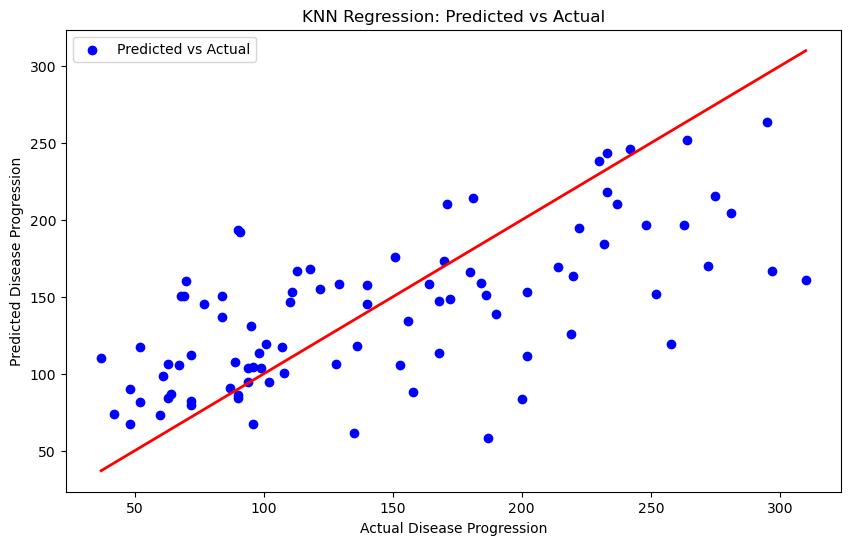

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2,)
plt.title('KNN Regression: Predicted vs Actual')
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.legend()
plt.show()   